# Análise de Métricas e Validação do Agente Crítico

Este notebook executa o ciclo `Code Analyst` <-> `Critic Agent` e coleta métricas de qualidade, custo e alucinação.

In [1]:
import os
import sys
import pandas as pd
import time # Importar time para medir tempo de execução com time.time() se necessário

# Adicionar src ao path para importações funcionarem
nb_dir = os.path.split(os.getcwd())[0]
if nb_dir not in sys.path:
    sys.path.append(nb_dir)

from src.code_analyst import analyze_codebase
from src.agents.critic import CriticAgent
from src.config import settings

# Configuração do Alvo (O próprio projeto)
PROJECT_PATH = input("Qual projeto será analisado? ").strip()
PROJECT_NAME = PROJECT_PATH.split("\\")[-1]


print(f"Analisando projeto em: {PROJECT_PATH}")

Analisando projeto em: C:\Projetos Estudos\calculadora


## Definição do Loop de Feedback

In [2]:
# Classe Mock para quando não houver API Key
class MockCritic:
    def review(self, text, path):
         return {} 

def run_analysis_loop(max_retries=3):
    # Verificação de API Key para usar Mock se necessário
    use_mock = os.getenv("OPENROUTER_API_KEY") is None
    
    if use_mock:
        print("AVISO: API Key não encontrada. Usando Mocks para simulação.")
        critic = MockCritic()
    else:
        critic = CriticAgent()
        
    history = []
    
    current_feedback = None
    final_doc = None
    
    for i in range(max_retries + 1):
        print(f"\n--- Iteração {i} ---")
        start_time = time.time()
        
        # 1. Executar Analyst
        print("Executando Code Analyst...")
        
        if use_mock:
            # Mock do Analyst
            time.sleep(1)
            if i == 0:
                 doc_text = "Docs v1 com erro. Arquivo: `src/ghost.py`"
                 steps = 5
            else:
                 doc_text = "Docs v2 corrigido. Arquivo: `src/code_analyst.py`"
                 steps = 8
            analyst_result = {"final_answer": doc_text, "steps": steps, "usage": {"total_tokens": 500}}
        else:
            try:
                analyst_result = analyze_codebase(PROJECT_PATH, PROJECT_NAME, feedback=current_feedback)
            except Exception as e:
                print(f"Erro no Analyst: {e}")
                break
        
        doc_text = analyst_result.get("final_answer", "")
        usage = analyst_result.get("usage", {})
        steps = analyst_result.get("steps", 0)
        
        # 2. Executar Critic
        print("Executando Critic Agent...")
        
        if use_mock:
             # Mock do Critic
             if i == 0:
                 review_result = {"approved": False, "score": 4, "feedback": "Alucinação.", "hallucinations": ["src/ghost.py"]}
             else:
                 review_result = {"approved": True, "score": 9, "feedback": "Aprovado.", "hallucinations": []}
        else:
             review_result = critic.review(doc_text, PROJECT_PATH)
        
        end_time = time.time()
        duration = end_time - start_time
        
        # Registrar Métricas
        metrics = {
            "iteration": i,
            "duration_sec": round(duration, 2),
            "analyst_steps": steps,
            "quality_score": review_result.get("score", 0),
            "hallucinations_count": len(review_result.get("hallucinations", [])),
            "approved": review_result.get("approved", False),
            "feedback_length": len(review_result.get("feedback", "")),
            "total_tokens": usage.get("total_tokens", 0) # Se disponível
        }
        history.append(metrics)
        
        print(f"Resultado: Aprovado={review_result.get('approved', False)} | Score={review_result.get('score', 0)} | Alucinações={len(review_result.get('hallucinations', []))}")
        
        if review_result.get('approved', False):
            final_doc = doc_text
            print("Documentação Aprovada!")
            break
        else:
            current_feedback = review_result.get('feedback', 'Sem feedback')
            print(f"Feedback para melhoria: {current_feedback[:200]}...")
    
    return history, final_doc


## Execução e Coleta de Dados

In [3]:
# Executar o loop (pode levar alguns minutos)
metrics_history, final_documentation = run_analysis_loop(max_retries=2)


--- Iteração 0 ---
Executando Code Analyst...
2026-01-14 20:27:21,107 | INFO     | Passo: Inicialização        | Tokens: 0      | Iniciando Agente ReAct para objetivo: 
    Você é um Arquiteto de Software Sênior especi...
2026-01-14 20:27:34,822 | INFO     | Passo: Inicialização        | Tokens: 1331   | Executando ferramenta: read_project_files com entrada: C:\Projetos Estudos\calculadora
  [Tool] Reading files from: C:\Projetos Estudos\calculadora
2026-01-14 20:31:39,198 | INFO     | Passo: Inicialização        | Tokens: 11233  | Agente alcançou a resposta final.
Executando Critic Agent...
2026-01-14 20:31:39,202 | INFO     | Passo: Inicialização        | Tokens: 11233  | Iniciando Agente ReAct para objetivo: 
        Você é um Crítico de Código e Documentaçã...
2026-01-14 20:32:40,280 | INFO     | Passo: Inicialização        | Tokens: 15451  | Agente alcançou a resposta final.
Resultado: Aprovado=False | Score=5.0 | Alucinações=8
Feedback para melhoria: Problemas de Alucinação dete

## Resultados e Métricas

,iteration,duration_sec,analyst_steps,quality_score,hallucinations_count,approved,feedback_length,total_tokens
0,0,319.44,2,5.0,8,False,884,9902
1,1,292.58,2,6.0,5,False,888,9613
2,2,343.69,2,6.5,1,False,1030,10535


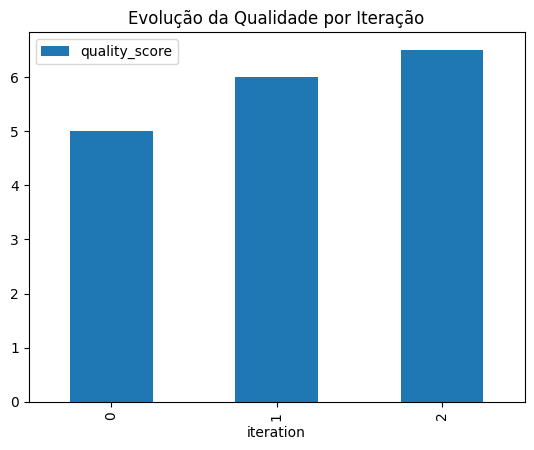

In [4]:
df = pd.DataFrame(metrics_history)
display(df)

# Exemplo de visualização simples
if not df.empty:
    try:
        df.plot(x='iteration', y='quality_score', kind='bar', title='Evolução da Qualidade por Iteração')
    except ImportError:
        print("Matplotlib não instalado, pulando gráfico.")

In [6]:
print("Documentação Final:")
if final_documentation:
    print(final_documentation[:1000] + "...")
else:
    print("A documentação não foi aprovada pelo Crítico após as tentativas.")

Documentação Final:
A documentação não foi aprovada pelo Crítico após as tentativas.
